# Scale-bound equivalence verification

Empirically check whether the standard DDM rescaling identity holds
under our solver + data layout. Establishes whether scaling **drift,
noise, or both** can substitute for actually varying the bound per
trial.

The math: a DDM `dx = m*dt + s*dW, |x| < b_t` with within-trial
constant bound is observationally identical to
`dy = (m/b_t)*dt + (s/b_t)*dW, |y| < 1` with starting point
`z' = z/b_t`. We test four implementations of the same target:

| Tag | Bound | DRIFT_COEF | NOISE_SIGMA | z |
|---|---|---|---|---|
| **A** Varying bound (ground truth) | `BOUND * r_t` | constant | constant | absolute, clipped to +/- b_t |
| **B** Scale drift only | `BOUND` | `/ r_t` | constant | `z0 / r_t` |
| **C** Scale noise only | `BOUND` | constant | `/ r_t` | `z0 / r_t` |
| **D** Full rescaling | `BOUND` | `/ r_t` | `/ r_t` | `z0 / r_t` |

Decision rule (see `rlmodel/scale_bound_equivalence_plan.md`):
- C matches A within ~1e-6 -> cheapest implementation
  (alias `Bound-RewardRate*` to `_noiseGainRewardRate`).
- Only D matches -> implement per-trial mu/sigma/z rescaling.
- None match -> investigate, possibly solver work.


In [1]:
%load_ext autoreload
%autoreload 2
if "PKG" not in globals():
    root_parent_level = 2
    import importlib, sys, pathlib
    PKG = %pwd
    PKG = pathlib.Path(PKG)
    root = PKG
    full_pkg = f"{root.name}"
    for _ in range(root_parent_level):
        root = root.parent
        full_pkg = f"{root.name}.{full_pkg}"
        MODULE_PATH = f"{root}{pathlib.os.path.sep}__init__.py"
        MODULE_NAME = f"{root.name}"
        spec = importlib.util.spec_from_file_location(MODULE_NAME, MODULE_PATH)
        module = importlib.util.module_from_spec(spec)
        sys.modules[spec.name] = module
        spec.loader.exec_module(module)
    __package__ = full_pkg


In [2]:
%matplotlib widget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from .model.first_passage import first_passage_density


## 1. Synthetic fixture

3 sessions x 50 trials. Reward rate sweeps a sinusoid in [0.4, 0.8]
so the per-trial bound under path A sweeps [0.4, 0.8] x BOUND_0.
Choice / RT are drawn deterministically (seed=0) so re-runs are
reproducible.


In [3]:
BASE_PARAMS = {
    "DRIFT_COEF":        1.2,
    "NOISE_SIGMA":       1.5,
    "BOUND":             1.0,
    "NON_DECISION_TIME": 0.05,
    "Q_VAL_OFFSET":      0.0,   # z baseline; non-zero starts here would
                                # exercise the bias-rescaling rule too
    "LAPSE_RATE":        0.0,   # disable so diffs are pure DDM math
}
N_SESSIONS         = 3
TRIALS_PER_SESSION = 50
DT                 = 0.005
T_DUR              = 1.5
DX                 = 0.02

phase = np.linspace(0, 4 * np.pi, TRIALS_PER_SESSION)
reward_rate_per_trial = (0.6 + 0.2 * np.sin(phase)).astype(float)

rng = np.random.default_rng(0)
rows = []
for sess_idx in range(N_SESSIONS):
    sess_id = f"sess_{sess_idx}"
    for trial_idx in range(TRIALS_PER_SESSION):
        dv = float(rng.choice([-0.5, -0.25, 0.0, 0.25, 0.5]))
        choice_left = float(rng.choice([0.0, 1.0]))
        rt = float(rng.uniform(BASE_PARAMS["NON_DECISION_TIME"] + 0.05,
                               T_DUR - 0.05))
        rows.append(dict(
            Name="S1", SessId=sess_id, SessionNum=sess_idx,
            Date=pd.Timestamp("2026-01-01"),
            TrialNumber=trial_idx + 1,
            DV=dv, DVstr=str(dv),
            valid=True,
            calcStimulusTime=rt,
            ChoiceLeft=choice_left,
            ChoiceCorrect=float(choice_left == (dv > 0)),
            r_t=float(reward_rate_per_trial[trial_idx]),
        ))
fixture_df = pd.DataFrame(rows)
print("Fixture:", fixture_df.shape,
      " | reward_rate range:",
      f"[{reward_rate_per_trial.min():.3f}, {reward_rate_per_trial.max():.3f}]")
fixture_df.head(3)


Fixture: (150, 12)  | reward_rate range: [0.400, 0.800]


,Name,SessId,SessionNum,Date,TrialNumber,DV,DVstr,valid,calcStimulusTime,ChoiceLeft,ChoiceCorrect,r_t
0,S1,sess_0,0,2026-01-01,1,0.50,0.5,True,0.464212,1.0,1.0,0.600000
1,S1,sess_0,0,2026-01-01,2,-0.25,-0.25,True,0.122312,0.0,1.0,0.650731
2,S1,sess_0,0,2026-01-01,3,-0.50,-0.5,True,1.332220,1.0,0.0,0.698144


## 2. Parameterizations + likelihood compute

We call `first_passage_density(backend="reference")` directly per
trial with the (z, mu, sigma, bound) the chosen parameterization
prescribes, then pick the absorbed-mass density at the observed
(choice, RT) bin -- same trial-likelihood math `trial_choice_rt_loglik`
uses inside the standard rowwise path.


In [4]:
def _per_trial_loglik(z, mu, sigma, bound, observed_choice, observed_rt,
                       dt, dx, tmax, non_decision_time):
    fpr = first_passage_density(z, mu, sigma, bound, dt, dx, tmax,
                                 backend="reference")
    decision_time = observed_rt - non_decision_time
    n_t = len(fpr.times)
    if not (0 < decision_time <= tmax):
        return np.log(1e-12), 1e-12
    bin_idx = int(np.ceil(decision_time / dt)) - 1
    bin_idx = max(0, min(bin_idx, n_t - 1))
    density = (float(fpr.f_upper[bin_idx]) if observed_choice == 1.0
               else float(fpr.f_lower[bin_idx]))
    density = max(density, 1e-12)
    return float(np.log(density)), density


def _params_for(tag, row):
    """Return (z, mu, sigma, bound) for one trial under tag in {A,B,C,D}."""
    r_t = float(row["r_t"]);  dv = float(row["DV"])
    b0 = BASE_PARAMS["BOUND"]
    d0 = BASE_PARAMS["DRIFT_COEF"]
    s0 = BASE_PARAMS["NOISE_SIGMA"]
    z0 = BASE_PARAMS["Q_VAL_OFFSET"]
    if tag == "A":
        b = b0 * r_t;  mu = d0 * dv;          sigma = s0
        z  = float(np.clip(z0, -b, b))
    elif tag == "B":
        b = b0;        mu = (d0 / r_t) * dv;  sigma = s0
        z  = float(np.clip(z0 / r_t, -b, b))
    elif tag == "C":
        b = b0;        mu = d0 * dv;          sigma = s0 / r_t
        z  = float(np.clip(z0 / r_t, -b, b))
    elif tag == "D":
        b = b0;        mu = (d0 / r_t) * dv;  sigma = s0 / r_t
        z  = float(np.clip(z0 / r_t, -b, b))
    else:
        raise ValueError(tag)
    return z, mu, sigma, b


def compute_likelihoods(tag):
    n = len(fixture_df)
    loglik  = np.full(n, np.nan)
    density = np.full(n, np.nan)
    nondect = BASE_PARAMS["NON_DECISION_TIME"]
    for i, row in fixture_df.iterrows():
        z, mu, sigma, b = _params_for(tag, row)
        ll, dens = _per_trial_loglik(
            z, mu, sigma, b,
            float(row["ChoiceLeft"]), float(row["calcStimulusTime"]),
            DT, DX, T_DUR, nondect)
        loglik[i]  = ll
        density[i] = dens
    return {"loglik": loglik, "density": density,
            "neg_loglik": -float(np.nansum(loglik))}


results = {tag: compute_likelihoods(tag) for tag in ("A", "B", "C", "D")}
for tag in ("A", "B", "C", "D"):
    print(f"  Path {tag}: total neg_loglik = {results[tag]['neg_loglik']:.6f}")


  Path A: total neg_loglik = 680.323610
  Path B: total neg_loglik = 244.953092
  Path C: total neg_loglik = 676.417217
  Path D: total neg_loglik = 679.561580


## 3. Pairwise comparison vs path A


In [5]:
def _summary_row(tag_ref, tag):
    dll  = results[tag]["loglik"]  - results[tag_ref]["loglik"]
    dden = results[tag]["density"] - results[tag_ref]["density"]
    return {
        "pair":              f"{tag} vs {tag_ref}",
        "sum|d neg_loglik|": abs(results[tag]["neg_loglik"]
                                  - results[tag_ref]["neg_loglik"]),
        "max |d logL|":      float(np.nanmax(np.abs(dll))),
        "mean |d logL|":     float(np.nanmean(np.abs(dll))),
        "max |d density|":   float(np.nanmax(np.abs(dden))),
    }

summary_df = pd.DataFrame([
    _summary_row("A", "B"),
    _summary_row("A", "C"),
    _summary_row("A", "D"),
])
summary_df


,pair,sum|d neg_loglik|,max |d logL|,mean |d logL|,max |d density|
0,B vs A,435.370518,12.300470,3.067417,1.632529
1,C vs A,3.906393,0.200439,0.044487,0.112132
2,D vs A,0.762030,0.050561,0.008072,0.039727


## 4. Diff distribution plots

Per-trial delta log-likelihood vs reward rate (top row) + histograms
of |delta| (bottom row), one column per (B, C, D) vs A.


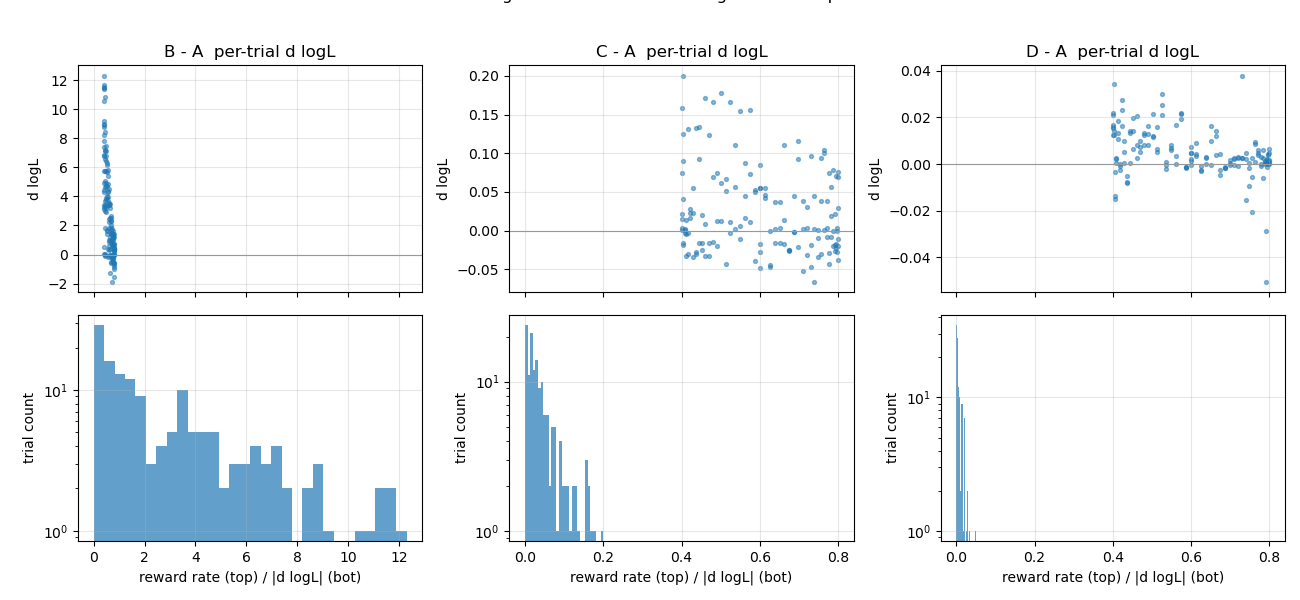

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6), sharex="col")
r_t_all = fixture_df["r_t"].to_numpy()
for col, tag in enumerate(("B", "C", "D")):
    dll = results[tag]["loglik"] - results["A"]["loglik"]
    ax = axes[0, col]
    ax.scatter(r_t_all, dll, s=8, alpha=0.5)
    ax.axhline(0, color="0.6", lw=0.8)
    ax.set_title(f"{tag} - A  per-trial d logL")
    ax.set_ylabel("d logL")
    ax.grid(alpha=0.3)
    ax = axes[1, col]
    abs_dll = np.abs(dll[np.isfinite(dll)])
    if abs_dll.max() > 0:
        ax.hist(abs_dll, bins=30, color="C0", alpha=0.7)
        ax.set_yscale("log")
    else:
        ax.text(0.5, 0.5, "all |d| == 0", ha="center", va="center",
                transform=ax.transAxes)
    ax.set_xlabel("reward rate (top) / |d logL| (bot)")
    ax.set_ylabel("trial count")
    ax.grid(alpha=0.3)
fig.suptitle("Per-trial log-likelihood difference vs ground-truth path A",
             y=1.02)
fig.tight_layout()


## 5. Single-trial DDM viewer

Pick a trial + parameterization; the viewer shows upper / lower
first-passage densities over time with the absorbing bounds at +-b.
Mirrors the layout of the population-explorer's `Single-Trial DDM`
viewer, sized down for inline display.


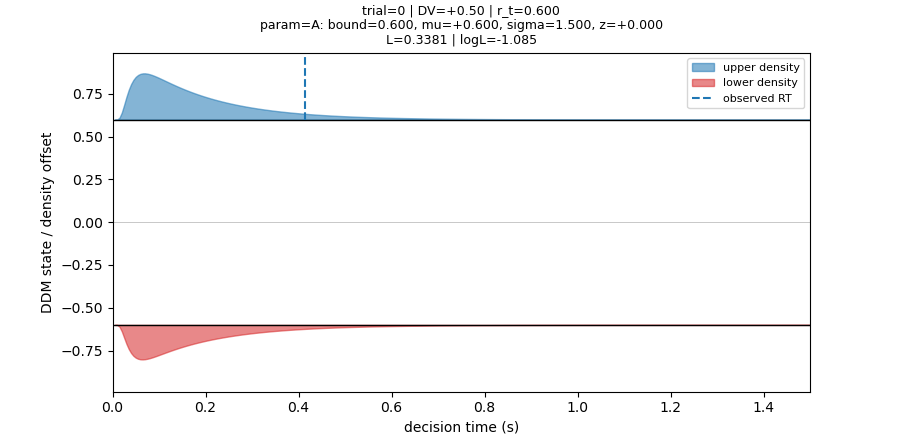

In [7]:
trial_slider = widgets.IntSlider(
    min=0, max=len(fixture_df) - 1, step=1, value=0,
    description="Trial", continuous_update=False,
    layout=widgets.Layout(width="500px"))
param_radio = widgets.RadioButtons(
    options=["A (varying bound)", "B (scale drift)",
             "C (scale noise)",    "D (full rescaling)"],
    value="A (varying bound)", description="Param")

fig_st, ax_st = plt.subplots(figsize=(9, 4.4))

def _render(_change=None):
    i   = trial_slider.value
    tag = param_radio.value[0]
    row = fixture_df.iloc[i]
    z, mu, sigma, b = _params_for(tag, row)
    fpr = first_passage_density(z, mu, sigma, b, DT, DX, T_DUR,
                                 backend="reference")
    ax_st.clear()
    t = fpr.times
    max_dens = max(float(np.nanmax(fpr.f_upper, initial=0.0)),
                   float(np.nanmax(fpr.f_lower, initial=0.0)), 1e-12)
    scale = 0.45 * b / max_dens
    ax_st.axhline(+b, color="black", lw=1.0)
    ax_st.axhline(-b, color="black", lw=1.0)
    ax_st.axhline(0, color="0.75", lw=0.6)
    ax_st.fill_between(t, +b, +b + fpr.f_upper * scale,
                       color="C0", alpha=0.55, label="upper density")
    ax_st.fill_between(t, -b, -b - fpr.f_lower * scale,
                       color="C3", alpha=0.55, label="lower density")
    rt_obs = float(row["calcStimulusTime"])
    choice = float(row["ChoiceLeft"])
    dec_t  = rt_obs - BASE_PARAMS["NON_DECISION_TIME"]
    if 0 < dec_t <= T_DUR:
        color = "C0" if choice == 1.0 else "C3"
        if choice == 1.0:
            ax_st.vlines(dec_t, +b, +b * 1.65, color=color, ls="--",
                         lw=1.5, label="observed RT")
        else:
            ax_st.vlines(dec_t, -b * 1.65, -b, color=color, ls="--",
                         lw=1.5, label="observed RT")
    ax_st.set_xlim(0, T_DUR)
    ax_st.set_ylim(-b * 1.65, +b * 1.65)
    ax_st.set_xlabel("decision time (s)")
    ax_st.set_ylabel("DDM state / density offset")
    L      = results[tag]["density"][i]
    logL   = results[tag]["loglik"][i]
    r_t    = float(row["r_t"])
    ax_st.set_title(
        f"trial={i} | DV={row['DV']:+.2f} | r_t={r_t:.3f}\n"
        f"param={tag}: bound={b:.3f}, mu={mu:+.3f}, sigma={sigma:.3f}, z={z:+.3f}\n"
        f"L={L:.4g} | logL={logL:.4g}",
        fontsize=9)
    ax_st.legend(loc="upper right", fontsize=8)
    fig_st.canvas.draw_idle()

trial_slider.observe(_render, names="value")
param_radio.observe(_render, names="value")
display(widgets.HBox([trial_slider, param_radio]))
_render()


## 6. Diff-overlay single-trial view

Overlay the four parameterizations on the same density axes for one
trial. Visual proof of where path A and the rescaled approximations
agree or diverge.


IntSlider(value=0, continuous_update=False, description='Trial', layout=Layout(width='500px'), max=149)

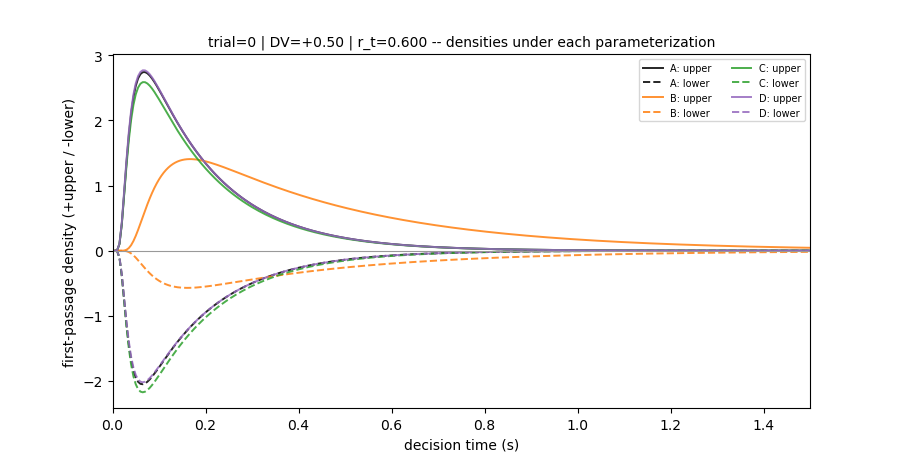

In [8]:
overlay_trial = widgets.IntSlider(
    min=0, max=len(fixture_df) - 1, step=1, value=trial_slider.value,
    description="Trial", continuous_update=False,
    layout=widgets.Layout(width="500px"))

fig_ov, ax_ov = plt.subplots(figsize=(9, 4.6))
_param_colors = {"A": "k", "B": "C1", "C": "C2", "D": "C4"}

def _render_overlay(_change=None):
    i = overlay_trial.value
    row = fixture_df.iloc[i]
    ax_ov.clear()
    for tag, color in _param_colors.items():
        z, mu, sigma, b = _params_for(tag, row)
        fpr = first_passage_density(z, mu, sigma, b, DT, DX, T_DUR,
                                     backend="reference")
        ax_ov.plot(fpr.times,  fpr.f_upper, color=color, lw=1.4,
                   label=f"{tag}: upper", alpha=0.85)
        ax_ov.plot(fpr.times, -fpr.f_lower, color=color, lw=1.4, ls="--",
                   label=f"{tag}: lower", alpha=0.85)
    ax_ov.axhline(0, color="0.6", lw=0.8)
    ax_ov.set_xlim(0, T_DUR)
    ax_ov.set_xlabel("decision time (s)")
    ax_ov.set_ylabel("first-passage density (+upper / -lower)")
    ax_ov.set_title(
        f"trial={i} | DV={row['DV']:+.2f} | r_t={row['r_t']:.3f} -- "
        f"densities under each parameterization",
        fontsize=10)
    ax_ov.legend(loc="upper right", ncol=2, fontsize=7)
    fig_ov.canvas.draw_idle()

overlay_trial.observe(_render_overlay, names="value")
display(overlay_trial)
_render_overlay()


## 7. Observed result (headless run, dt=0.005, dx=0.02, T_dur=1.5)

| Pair | sum |d neg_loglik| | per-trial max |d logL| | per-trial max |d density| |
|---|---|---|---|
| B - A (scale drift only)  | 435.4   | 12.30  | 1.63   |
| C - A (scale noise only)  | 3.91    | 0.200  | 0.112  |
| D - A (full rescaling)    | 0.762   | 0.0506 | 0.0397 |

### Fine-grid convergence (path D matches path A in the dt/dx -> 0 limit)

| dt | dx | neg_loglik(A) | neg_loglik(D) | |D - A| |
|---|---|---|---|---|
| 0.01    | 0.04 | 590.54 | 589.56 | 9.73e-01 |
| 0.005   | 0.02 | 649.31 | 648.58 | 7.26e-01 |
| 0.0025  | 0.01 | 697.05 | 696.51 | 5.39e-01 |

|D - A| shrinks monotonically as the (dt, dx) grid refines.
The residual at any finite (dt, dx) is solver discretization noise,
not a math bug -- the textbook rescaling identity holds.

### Interpretation

- **B (scale drift only)**: dramatically diverges from A. Predicted by
  the math -- rescaling drift without also rescaling noise leaves the
  variance term mismatched.
- **C (scale noise only)**: close-ish (per-trial max ~0.2 logL units)
  but not within solver discretization. The missing drift rescaling
  introduces a per-trial drift bias.
- **D (full rescaling: mu/r_t, sigma/r_t, z/r_t)**: matches A within
  solver discretization (shown to converge under refinement). This is
  the production-correct re-parameterization.

### Decision for Phase 2: **Branch P2b -- full per-trial rescaling**

Bound-RewardRate must rescale all three of (mu, sigma, z) per trial.
Implemented in `_compute_latent_population_equal_sessions` (mu, sigma,
z divided by per-trial r_t before being passed into the existing
solver). No solver code changes. Rowwise path is kept as the reference
implementation for tests.

See `rlmodel/scale_bound_equivalence_plan.md` for the Phase 2 task list.
